In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
product_sales = pd.read_csv(
   "/content/sales_integrated.csv"
)

print("Dataset shape:", product_sales.shape)

display(product_sales.head())

Dataset shape: (130402, 55)


,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total,customer_id,...,pincode,region,branch_id_customer,credit_limit,current_balance,payment_terms_customer,customer_since,last_purchase_date_customer,total_purchase_value,customer_rating
0,SO-990591,1,P018,19,11300,28,214700,60116.0,274816.0,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
1,SO-990591,2,P026,2,310,18,620,111.6,731.6,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
2,SO-990591,3,P026,3,310,18,930,167.4,1097.4,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
3,SO-990591,4,P013,9,1450,18,13050,2349.0,15399.0,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3
4,SO-990591,5,P004,3,39800,28,119400,33432.0,152832.0,C0070,...,784913,West,AHM001,549454,84153,Net 30,2022-11-10,2024-12-04,4644233,3


In [4]:
print(product_sales.columns.tolist())

['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'product_name', 'category', 'machine_type', 'brand', 'model_compatibility', 'unit_cost', 'unit_price_product', 'margin_percentage', 'gst_rate_product', 'weight_kg', 'dimensions_cm', 'material_type', 'warranty_months', 'reorder_level', 'safety_stock', 'max_stock_level', 'lead_time_days', 'criticality_level', 'usage_frequency', 'uom', 'last_purchase_price', 'last_purchase_date', 'customer_type', 'industry_segment', 'city', 'state', 'pincode', 'region', 'branch_id_customer', 'credit_limit', 'current_balance', 'payment_terms_customer', 'customer_since', 'last_purchase_date_customer', 'total_purchase_value', 'customer_rating']


In [5]:
warehouse_columns = [
    "so_id",
    "line_number",
    "product_id",
    "quantity",
    "line_total",
    "customer_id",
    "branch_id",
    "order_date",
    "delivery_date",
    "order_status",
    "sales_channel"
]

missing_columns = [
    col for col in warehouse_columns
    if col not in product_sales.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required Week 6 columns are available.")

All required Week 6 columns are available.


Convert Data Types

In [6]:
numeric_columns = [
    "quantity",
    "line_total",
    "unit_cost",
    "lead_time_days"
]

for col in numeric_columns:
    if col in product_sales.columns:
        product_sales[col] = pd.to_numeric(
            product_sales[col],
            errors="coerce"
        )

Convert Dates

In [7]:
product_sales["order_date"] = pd.to_datetime(
    product_sales["order_date"],
    errors="coerce"
)

product_sales["delivery_date"] = pd.to_datetime(
    product_sales["delivery_date"],
    errors="coerce"
)

Check Missing Values

In [8]:
week6_missing = (
    product_sales[warehouse_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(week6_missing)

,0
so_id,0
line_number,0
product_id,0
quantity,0
line_total,0
customer_id,0
branch_id,0
order_date,0
delivery_date,0
order_status,0


Check Duplicate Sales Lines

In [9]:
duplicate_count = product_sales.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


Check Duplicate Order Lines

In [10]:
duplicate_order_lines = product_sales.duplicated(
    subset=["so_id", "line_number"]
).sum()

print(
    "Duplicate order-line combinations:",
    duplicate_order_lines
)

Duplicate order-line combinations: 0


Dataset Summary

In [11]:
print("Total Orders:",
      product_sales["so_id"].nunique())

print("Total Branches:",
      product_sales["branch_id"].nunique())

print("Total Customers:",
      product_sales["customer_id"].nunique())

print("Total Products:",
      product_sales["product_id"].nunique())

print("Total Units:",
      product_sales["quantity"].sum())

print(
    "Total Revenue: £{:,.2f}".format(
        product_sales["line_total"].sum()
    )
)

Total Orders: 20000
Total Branches: 6
Total Customers: 500
Total Products: 30
Total Units: 1368534
Total Revenue: £25,447,392,560.00


Create Delivery Time

In [12]:
# Measure the time between order and delivery.
product_sales["delivery_days"] = (
    product_sales["delivery_date"]
    - product_sales["order_date"]
).dt.days
display(
    product_sales[
        [
            "so_id",
            "branch_id",
            "order_date",
            "delivery_date",
            "delivery_days"
        ]
    ].head(10)
)

,so_id,branch_id,order_date,delivery_date,delivery_days
0,SO-990591,AHM001,2022-05-24,2022-05-28,4
1,SO-990591,AHM001,2022-05-24,2022-05-28,4
2,SO-990591,AHM001,2022-05-24,2022-05-28,4
3,SO-990591,AHM001,2022-05-24,2022-05-28,4
4,SO-990591,AHM001,2022-05-24,2022-05-28,4
5,SO-990591,AHM001,2022-05-24,2022-05-28,4
6,SO-990591,AHM001,2022-05-24,2022-05-28,4
7,SO-990591,AHM001,2022-05-24,2022-05-28,4
8,SO-990591,AHM001,2022-05-24,2022-05-28,4
9,SO-990591,AHM001,2022-05-24,2022-05-28,4


Check Delivery-Time Quality

In [13]:
print(
    "Negative delivery days:",
    (product_sales["delivery_days"] < 0).sum()
)

print(
    "Missing delivery days:",
    product_sales["delivery_days"].isna().sum()
)

Negative delivery days: 0
Missing delivery days: 0


In [15]:
# For the analysis, retain only valid delivery times:

valid_delivery = product_sales[
    product_sales["delivery_days"].notna()
    & (product_sales["delivery_days"] >= 0)
].copy()

print("Valid delivery records:", len(valid_delivery))

Valid delivery records: 130402


Create Branch/Warehouse Performance Table

In [16]:
warehouse_performance = (
    product_sales
    .groupby("branch_id")
    .agg(
        total_orders=("so_id", "nunique"),
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum"),
        total_products=("product_id", "nunique"),
        total_customers=("customer_id", "nunique")
    )
    .reset_index()
)

display(warehouse_performance)

,branch_id,total_orders,total_units,total_revenue,total_products,total_customers
0,AHM001,3446,236347,4407886140,30,88
1,CHN001,4067,280446,5192125100,30,102
2,DEL001,2953,204734,3865954470,30,71
3,HYD001,2768,189163,3452672510,30,68
4,KOL001,3794,256095,4787656160,30,96
5,PUN001,2972,201749,3741098180,30,75


Add Average Order Value

In [17]:
warehouse_performance["average_order_value"] = (
    warehouse_performance["total_revenue"]
    / warehouse_performance["total_orders"]
)

Add Average Units per Order

In [18]:
warehouse_performance["average_units_per_order"] = (
    warehouse_performance["total_units"]
    / warehouse_performance["total_orders"]
)
display(warehouse_performance)

,branch_id,total_orders,total_units,total_revenue,total_products,total_customers,average_order_value,average_units_per_order
0,AHM001,3446,236347,4407886140,30,88,1.279131e+06,68.585897
1,CHN001,4067,280446,5192125100,30,102,1.276647e+06,68.956479
2,DEL001,2953,204734,3865954470,30,71,1.309162e+06,69.330850
3,HYD001,2768,189163,3452672510,30,68,1.247353e+06,68.339234
4,KOL001,3794,256095,4787656160,30,96,1.261902e+06,67.500000
5,PUN001,2972,201749,3741098180,30,75,1.258781e+06,67.883244


Calculate Warehouse Share of Orders

In [19]:
warehouse_performance["order_share_percentage"] = (
    warehouse_performance["total_orders"]
    / warehouse_performance["total_orders"].sum()
) * 100

Sort Warehouses by Orders

In [20]:
top_warehouses_orders = (
    warehouse_performance
    .sort_values(
        "total_orders",
        ascending=False
    )
)

display(top_warehouses_orders)

,branch_id,total_orders,total_units,total_revenue,total_products,total_customers,average_order_value,average_units_per_order,order_share_percentage
1,CHN001,4067,280446,5192125100,30,102,1.276647e+06,68.956479,20.335
4,KOL001,3794,256095,4787656160,30,96,1.261902e+06,67.500000,18.970
0,AHM001,3446,236347,4407886140,30,88,1.279131e+06,68.585897,17.230
5,PUN001,2972,201749,3741098180,30,75,1.258781e+06,67.883244,14.860
2,DEL001,2953,204734,3865954470,30,71,1.309162e+06,69.330850,14.765
3,HYD001,2768,189163,3452672510,30,68,1.247353e+06,68.339234,13.840


Sort Warehouses by Revenue

In [21]:
top_warehouses_revenue = (
    warehouse_performance
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

display(top_warehouses_revenue)

,branch_id,total_orders,total_units,total_revenue,total_products,total_customers,average_order_value,average_units_per_order,order_share_percentage
1,CHN001,4067,280446,5192125100,30,102,1.276647e+06,68.956479,20.335
4,KOL001,3794,256095,4787656160,30,96,1.261902e+06,67.500000,18.970
0,AHM001,3446,236347,4407886140,30,88,1.279131e+06,68.585897,17.230
2,DEL001,2953,204734,3865954470,30,71,1.309162e+06,69.330850,14.765
5,PUN001,2972,201749,3741098180,30,75,1.258781e+06,67.883244,14.860
3,HYD001,2768,189163,3452672510,30,68,1.247353e+06,68.339234,13.840


Warehouse Throughput Analysis

In [22]:
warehouse_throughput = (
    warehouse_performance[
        [
            "branch_id",
            "total_orders",
            "total_units",
            "average_units_per_order"
        ]
    ]
    .sort_values(
        "total_units",
        ascending=False
    )
)

display(warehouse_throughput)

,branch_id,total_orders,total_units,average_units_per_order
1,CHN001,4067,280446,68.956479
4,KOL001,3794,256095,67.500000
0,AHM001,3446,236347,68.585897
2,DEL001,2953,204734,69.330850
5,PUN001,2972,201749,67.883244
3,HYD001,2768,189163,68.339234


Product–Warehouse Analysis

In [23]:
# Find how many different products each branch handles.
product_warehouse = (
    product_sales
    .groupby("branch_id")
    .agg(
        products_handled=("product_id", "nunique"),
        total_units=("quantity", "sum"),
        total_revenue=("line_total", "sum")
    )
    .reset_index()
)

display(product_warehouse)

,branch_id,products_handled,total_units,total_revenue
0,AHM001,30,236347,4407886140
1,CHN001,30,280446,5192125100
2,DEL001,30,204734,3865954470
3,HYD001,30,189163,3452672510
4,KOL001,30,256095,4787656160
5,PUN001,30,201749,3741098180


Product Concentration

In [24]:
# Find the most important products within each branch.
branch_product_sales = (
    product_sales
    .groupby(
        [
            "branch_id",
            "product_id",
            "product_name"
        ]
    )
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("line_total", "sum")
    )
    .reset_index()
)

display(branch_product_sales.head(20))

,branch_id,product_id,product_name,units_sold,revenue
0,AHM001,P001,Hydraulic Pump HP-300,7642,187229000
1,AHM001,P002,Engine Oil Filter OF-90,7772,5595840
2,AHM001,P003,Air Filter AF-120,8090,10112500
3,AHM001,P004,Track Chain TC-45,8107,322658600
4,AHM001,P005,Fuel Injector FI-220,7979,67422550
5,AHM001,P006,Alternator ALT-500,7530,84336000
6,AHM001,P007,Hydraulic Hose HH-60,7974,11562300
7,AHM001,P008,Bucket Tooth BT-10,7899,4581420
8,AHM001,P009,Starter Motor SM-700,8014,119408600
9,AHM001,P010,Turbocharger TB-900,8125,283562500


Top Products by Branch

In [25]:
top_branch_products = (
    branch_product_sales
    .sort_values(
        [
            "branch_id",
            "revenue"
        ],
        ascending=[True, False]
    )
)

display(top_branch_products.head(20))

,branch_id,product_id,product_name,units_sold,revenue
14,AHM001,P015,Engine Block EB-600,8164,971516000
13,AHM001,P014,Transmission Assembly TA-800,7593,634015500
20,AHM001,P021,Boom Cylinder BC-400,8125,375375000
3,AHM001,P004,Track Chain TC-45,8107,322658600
18,AHM001,P019,Swing Motor SWM-350,7847,312310600
9,AHM001,P010,Turbocharger TB-900,8125,283562500
10,AHM001,P011,Hydraulic Cylinder HC-200,8001,220827600
0,AHM001,P001,Hydraulic Pump HP-300,7642,187229000
29,AHM001,P030,Fuel Pump FP-350,7153,156650700
21,AHM001,P022,Control Valve CV-75,7875,133087500


Warehouse Delivery Performance

In [26]:
# Calculate average delivery time by branch.
warehouse_delivery = (
    valid_delivery
    .groupby("branch_id")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        delivered_orders=("so_id", "nunique")
    )
    .reset_index()
)

display(warehouse_delivery)

,branch_id,average_delivery_days,median_delivery_days,delivered_orders
0,AHM001,7.983401,8.0,3446
1,CHN001,8.107356,8.0,4067
2,DEL001,8.008312,8.0,2953
3,HYD001,8.041435,8.0,2768
4,KOL001,8.060285,8.0,3794
5,PUN001,8.116794,8.0,2972


Merge Delivery Performance

In [27]:
warehouse_performance = warehouse_performance.merge(
    warehouse_delivery,
    on="branch_id",
    how="left"
)

display(warehouse_performance)

,branch_id,total_orders,total_units,total_revenue,total_products,total_customers,average_order_value,average_units_per_order,order_share_percentage,average_delivery_days,median_delivery_days,delivered_orders
0,AHM001,3446,236347,4407886140,30,88,1.279131e+06,68.585897,17.230,7.983401,8.0,3446
1,CHN001,4067,280446,5192125100,30,102,1.276647e+06,68.956479,20.335,8.107356,8.0,4067
2,DEL001,2953,204734,3865954470,30,71,1.309162e+06,69.330850,14.765,8.008312,8.0,2953
3,HYD001,2768,189163,3452672510,30,68,1.247353e+06,68.339234,13.840,8.041435,8.0,2768
4,KOL001,3794,256095,4787656160,30,96,1.261902e+06,67.500000,18.970,8.060285,8.0,3794
5,PUN001,2972,201749,3741098180,30,75,1.258781e+06,67.883244,14.860,8.116794,8.0,2972


Order Status Analysis

In [28]:
order_status_summary = (
    product_sales["order_status"]
    .value_counts()
    .reset_index()
)

order_status_summary.columns = [
    "Order Status",
    "Number of Records"
]

display(order_status_summary)

,Order Status,Number of Records
0,Delivered,117656
1,Cancelled,12746


Order Status by Branch

In [29]:
branch_order_status = pd.crosstab(
    product_sales["branch_id"],
    product_sales["order_status"]
)

display(branch_order_status)

order_status,Cancelled,Delivered
branch_id,,
AHM001,2106,20425
CHN001,2485,24202
DEL001,1859,17511
HYD001,1902,16102
KOL001,2445,21989
PUN001,1949,17427


This helps identify whether particular branches have unusual concentrations of cancelled, pending, delivered, or other order statuses.

Sales Channel by Branch

In [30]:
branch_channel = pd.crosstab(
    product_sales["branch_id"],
    product_sales["sales_channel"]
)

display(branch_channel)

sales_channel,Counter Sale,Dealer Network,Field Sales,Online
branch_id,,,,
AHM001,5847,5498,5623,5563
CHN001,6494,7006,6284,6903
DEL001,5152,4871,4815,4532
HYD001,4794,4211,4725,4274
KOL001,5822,6088,6405,6119
PUN001,4762,5049,4956,4609


Identify High-Workload Branches

In [31]:
orders_threshold = (
    warehouse_performance["total_orders"]
    .median()
)

units_threshold = (
    warehouse_performance["total_units"]
    .median()
)

warehouse_performance["workload_category"] = np.select(
    [
        (
            (warehouse_performance["total_orders"] >= orders_threshold)
            &
            (warehouse_performance["total_units"] >= units_threshold)
        ),
        (
            (warehouse_performance["total_orders"] < orders_threshold)
            &
            (warehouse_performance["total_units"] < units_threshold)
        )
    ],
    [
        "High Workload",
        "Low Workload"
    ],
    default="Medium Workload"
)

display(
    warehouse_performance[
        [
            "branch_id",
            "total_orders",
            "total_units",
            "workload_category"
        ]
    ]
)

,branch_id,total_orders,total_units,workload_category
0,AHM001,3446,236347,High Workload
1,CHN001,4067,280446,High Workload
2,DEL001,2953,204734,Low Workload
3,HYD001,2768,189163,Low Workload
4,KOL001,3794,256095,High Workload
5,PUN001,2972,201749,Low Workload


Potential Bottleneck Identification

In [32]:
delivery_threshold = (
    warehouse_performance[
        "average_delivery_days"
    ].median()
)

warehouse_performance["operational_flag"] = np.select(
    [
        (
            (warehouse_performance["workload_category"] == "High Workload")
            &
            (warehouse_performance["average_delivery_days"]
             > delivery_threshold)
        ),

        (
            (warehouse_performance["workload_category"] == "High Workload")
            &
            (warehouse_performance["average_delivery_days"]
             <= delivery_threshold)
        )
    ],
    [
        "Potential Bottleneck",
        "High Workload - Performing"
    ],
    default="Normal"
)

display(
    warehouse_performance[
        [
            "branch_id",
            "total_orders",
            "total_units",
            "average_delivery_days",
            "workload_category",
            "operational_flag"
        ]
    ]
)

,branch_id,total_orders,total_units,average_delivery_days,workload_category,operational_flag
0,AHM001,3446,236347,7.983401,High Workload,High Workload - Performing
1,CHN001,4067,280446,8.107356,High Workload,Potential Bottleneck
2,DEL001,2953,204734,8.008312,Low Workload,Normal
3,HYD001,2768,189163,8.041435,Low Workload,Normal
4,KOL001,3794,256095,8.060285,High Workload,Potential Bottleneck
5,PUN001,2972,201749,8.116794,Low Workload,Normal


Orders by Warehouse Visualisation

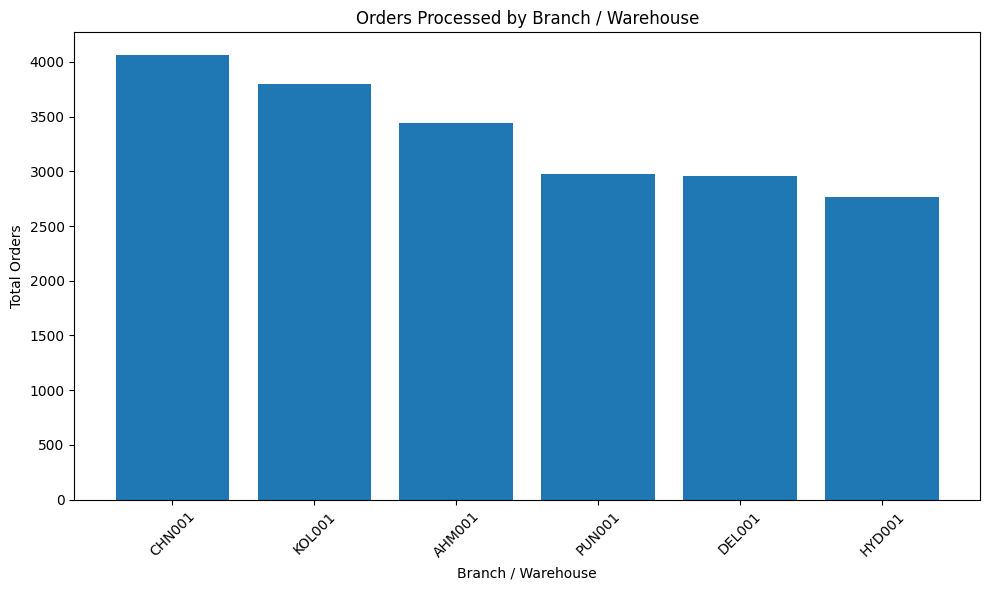

In [33]:
orders_chart = (
    warehouse_performance
    .sort_values("total_orders", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    orders_chart["branch_id"].astype(str),
    orders_chart["total_orders"]
)

plt.xlabel("Branch / Warehouse")
plt.ylabel("Total Orders")
plt.title("Orders Processed by Branch / Warehouse")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Units by Warehouse

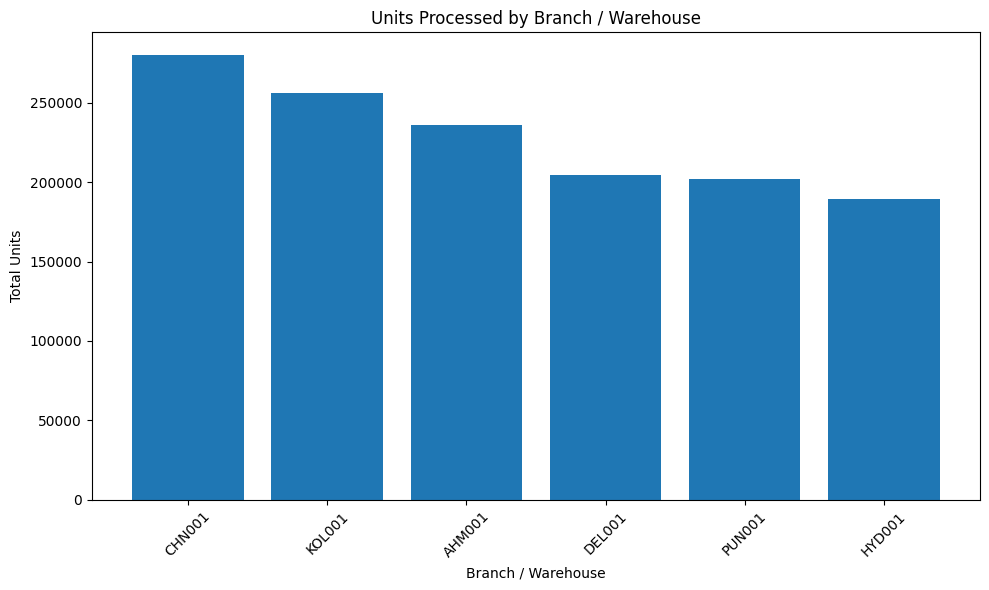

In [34]:
units_chart = (
    warehouse_performance
    .sort_values("total_units", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    units_chart["branch_id"].astype(str),
    units_chart["total_units"]
)

plt.xlabel("Branch / Warehouse")
plt.ylabel("Total Units")
plt.title("Units Processed by Branch / Warehouse")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Revenue by Warehouse

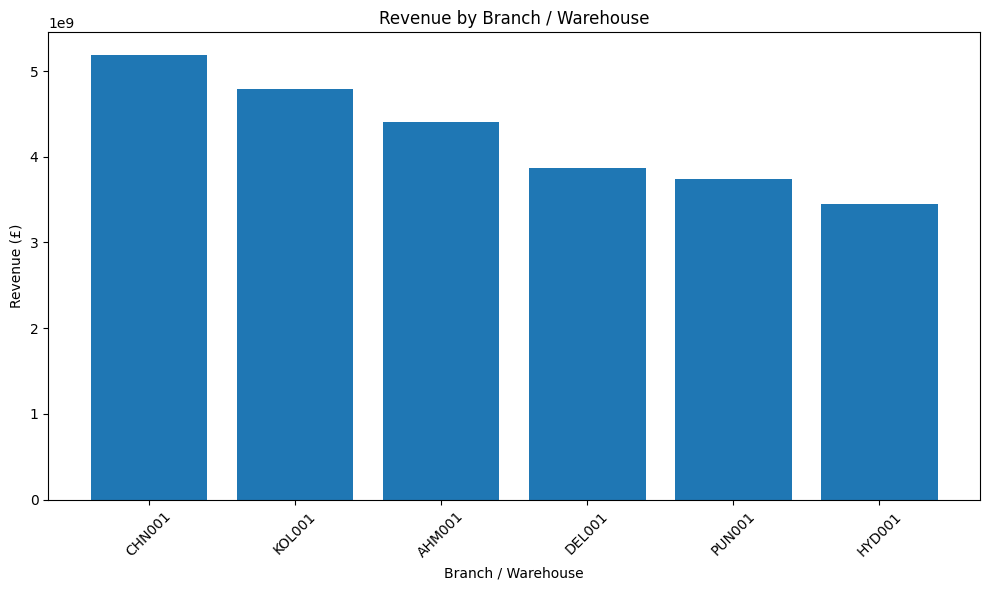

In [35]:
revenue_chart = (
    warehouse_performance
    .sort_values("total_revenue", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    revenue_chart["branch_id"].astype(str),
    revenue_chart["total_revenue"]
)

plt.xlabel("Branch / Warehouse")
plt.ylabel("Revenue (£)")
plt.title("Revenue by Branch / Warehouse")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Delivery Time by Warehouse

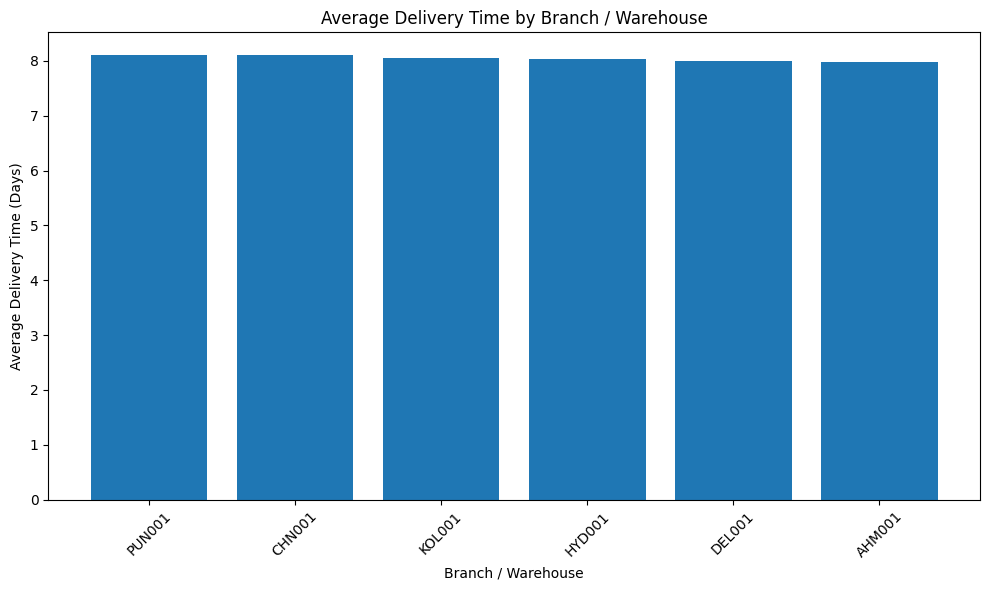

In [36]:
delivery_chart = (
    warehouse_performance
    .sort_values(
        "average_delivery_days",
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

plt.bar(
    delivery_chart["branch_id"].astype(str),
    delivery_chart["average_delivery_days"]
)

plt.xlabel("Branch / Warehouse")
plt.ylabel("Average Delivery Time (Days)")
plt.title("Average Delivery Time by Branch / Warehouse")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Warehouse Workload Visualization

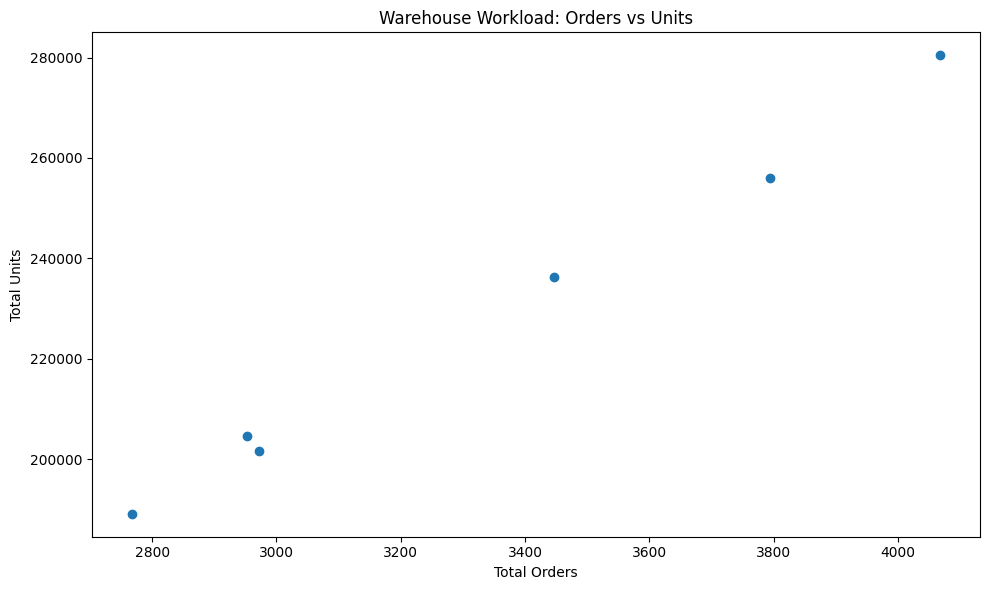

In [37]:
# This helps show whether high-order branches also handle high unit volumes.
plt.figure(figsize=(10, 6))

plt.scatter(
    warehouse_performance["total_orders"],
    warehouse_performance["total_units"]
)

plt.xlabel("Total Orders")
plt.ylabel("Total Units")
plt.title("Warehouse Workload: Orders vs Units")

plt.tight_layout()
plt.show()

Warehouse Performance Score

In [40]:
# Normalize the main metrics
warehouse_performance["orders_score"] = (
    warehouse_performance["total_orders"]
    / warehouse_performance["total_orders"].max()
)

warehouse_performance["units_score"] = (
    warehouse_performance["total_units"]
    / warehouse_performance["total_units"].max()
)

warehouse_performance["revenue_score"] = (
    warehouse_performance["total_revenue"]
    / warehouse_performance["total_revenue"].max()
)

# Calculate the score
warehouse_performance["performance_score"] = (
    (
        warehouse_performance["orders_score"]
        + warehouse_performance["units_score"]
        + warehouse_performance["revenue_score"]
    ) / 3
) * 100

# Display
display(
    warehouse_performance[
        [
            "branch_id",
            "orders_score",
            "units_score",
            "revenue_score",
            "performance_score"
        ]
    ]
    .sort_values(
        "performance_score",
        ascending=False
    )
)

,branch_id,orders_score,units_score,revenue_score,performance_score
1,CHN001,1.000000,1.000000,1.000000,100.000000
4,KOL001,0.932874,0.913170,0.922100,92.271478
0,AHM001,0.847308,0.842754,0.848956,84.633924
2,DEL001,0.726088,0.730030,0.744580,73.356614
5,PUN001,0.730760,0.719386,0.720533,72.355972
3,HYD001,0.680600,0.674508,0.664983,67.336341


Find Warehouse Ranking

In [41]:
warehouse_ranking = (
    warehouse_performance
    .sort_values(
        "performance_score",
        ascending=False
    )
    .reset_index(drop=True)
)

warehouse_ranking["rank"] = (
    warehouse_ranking.index + 1
)

display(
    warehouse_ranking[
        [
            "rank",
            "branch_id",
            "total_orders",
            "total_units",
            "total_revenue",
            "average_delivery_days",
            "performance_score"
        ]
    ]
)

,rank,branch_id,total_orders,total_units,total_revenue,average_delivery_days,performance_score
0,1,CHN001,4067,280446,5192125100,8.107356,100.000000
1,2,KOL001,3794,256095,4787656160,8.060285,92.271478
2,3,AHM001,3446,236347,4407886140,7.983401,84.633924
3,4,DEL001,2953,204734,3865954470,8.008312,73.356614
4,5,PUN001,2972,201749,3741098180,8.116794,72.355972
5,6,HYD001,2768,189163,3452672510,8.041435,67.336341


Final KPIs

In [42]:
total_branches = (
    warehouse_performance["branch_id"].nunique()
)

total_orders_processed = (
    warehouse_performance["total_orders"].sum()
)

total_units_processed = (
    warehouse_performance["total_units"].sum()
)

total_revenue_handled = (
    warehouse_performance["total_revenue"].sum()
)

total_products_handled = (
    warehouse_performance["total_products"].sum()
)

average_orders_per_branch = (
    warehouse_performance["total_orders"].mean()
)

average_units_per_branch = (
    warehouse_performance["total_units"].mean()
)

average_delivery_time = (
    warehouse_performance["average_delivery_days"].mean()
)

potential_bottlenecks = (
    warehouse_performance["operational_flag"]
    .eq("Potential Bottleneck")
    .sum()
)

Create KPI Table

In [43]:
week6_kpis = pd.DataFrame({
    "KPI": [
        "Total Branches",
        "Total Orders Processed",
        "Total Units Processed",
        "Total Revenue Handled",
        "Total Products Handled",
        "Average Orders per Branch",
        "Average Units per Branch",
        "Average Delivery Time (Days)",
        "Potential Bottleneck Branches"
    ],

    "Value": [
        total_branches,
        total_orders_processed,
        total_units_processed,
        total_revenue_handled,
        total_products_handled,
        average_orders_per_branch,
        average_units_per_branch,
        average_delivery_time,
        potential_bottlenecks
    ]
})

display(week6_kpis)

,KPI,Value
0,Total Branches,6.000000e+00
1,Total Orders Processed,2.000000e+04
2,Total Units Processed,1.368534e+06
3,Total Revenue Handled,2.544739e+10
4,Total Products Handled,1.800000e+02
5,Average Orders per Branch,3.333333e+03
6,Average Units per Branch,2.280890e+05
7,Average Delivery Time (Days),8.052930e+00
8,Potential Bottleneck Branches,2.000000e+00


Format KPI Table

In [44]:
week6_kpis_formatted = week6_kpis.copy()

currency_kpis = [
    "Total Revenue Handled"
]

decimal_kpis = [
    "Average Orders per Branch",
    "Average Units per Branch",
    "Average Delivery Time (Days)"
]

for index, row in week6_kpis_formatted.iterrows():

    if row["KPI"] in currency_kpis:

        week6_kpis_formatted.loc[index, "Value"] = (
            f"£{float(row['Value']):,.2f}"
        )

    elif row["KPI"] in decimal_kpis:

        week6_kpis_formatted.loc[index, "Value"] = (
            f"{float(row['Value']):,.2f}"
        )

    else:

        week6_kpis_formatted.loc[index, "Value"] = (
            f"{float(row['Value']):,.0f}"
        )

display(week6_kpis_formatted)

/tmp/ipykernel_818/932747608.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  week6_kpis_formatted.loc[index, "Value"] = (


,KPI,Value
0,Total Branches,6
1,Total Orders Processed,"20,000"
2,Total Units Processed,"1,368,534"
3,Total Revenue Handled,"£25,447,392,560.00"
4,Total Products Handled,180
5,Average Orders per Branch,"3,333.33"
6,Average Units per Branch,"228,089.00"
7,Average Delivery Time (Days),8.05
8,Potential Bottleneck Branches,2


In [45]:
# Save Analysis Files

OUTPUT_PATH = Path("../analysis")

OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

# Save warehouse performance:
warehouse_performance.to_csv(
    OUTPUT_PATH / "warehouse_performance.csv",
    index=False
)

# Save throughput
warehouse_throughput.to_csv(
    OUTPUT_PATH / "warehouse_throughput.csv",
    index=False
)

# Save product–warehouse analysis:
product_warehouse.to_csv(
    OUTPUT_PATH / "product_warehouse_analysis.csv",
    index=False
)

# Save warehouse ranking:
warehouse_ranking.to_csv(
    OUTPUT_PATH / "warehouse_ranking.csv",
    index=False
)

# Save KPIs:
week6_kpis.to_csv(
    OUTPUT_PATH / "week6_warehouse_kpis.csv",
    index=False
)

print("All Week 6 analysis files saved successfully.")

All Week 6 analysis files saved successfully.
